In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score, recall_score, classification_report, roc_auc_score, roc_curve
from sklearn.tree import plot_tree

In [2]:
df = pd.read_csv("breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
# Diagnosis being the independent variable

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [5]:
df.drop('id', axis=1, inplace=True)

### A little EDA

In [6]:
diagmapping = {"B": 0, "M": 1}

df["diag_encoded"] = df["diagnosis"].map(diagmapping)
df.drop('diagnosis', axis=1, inplace=True)

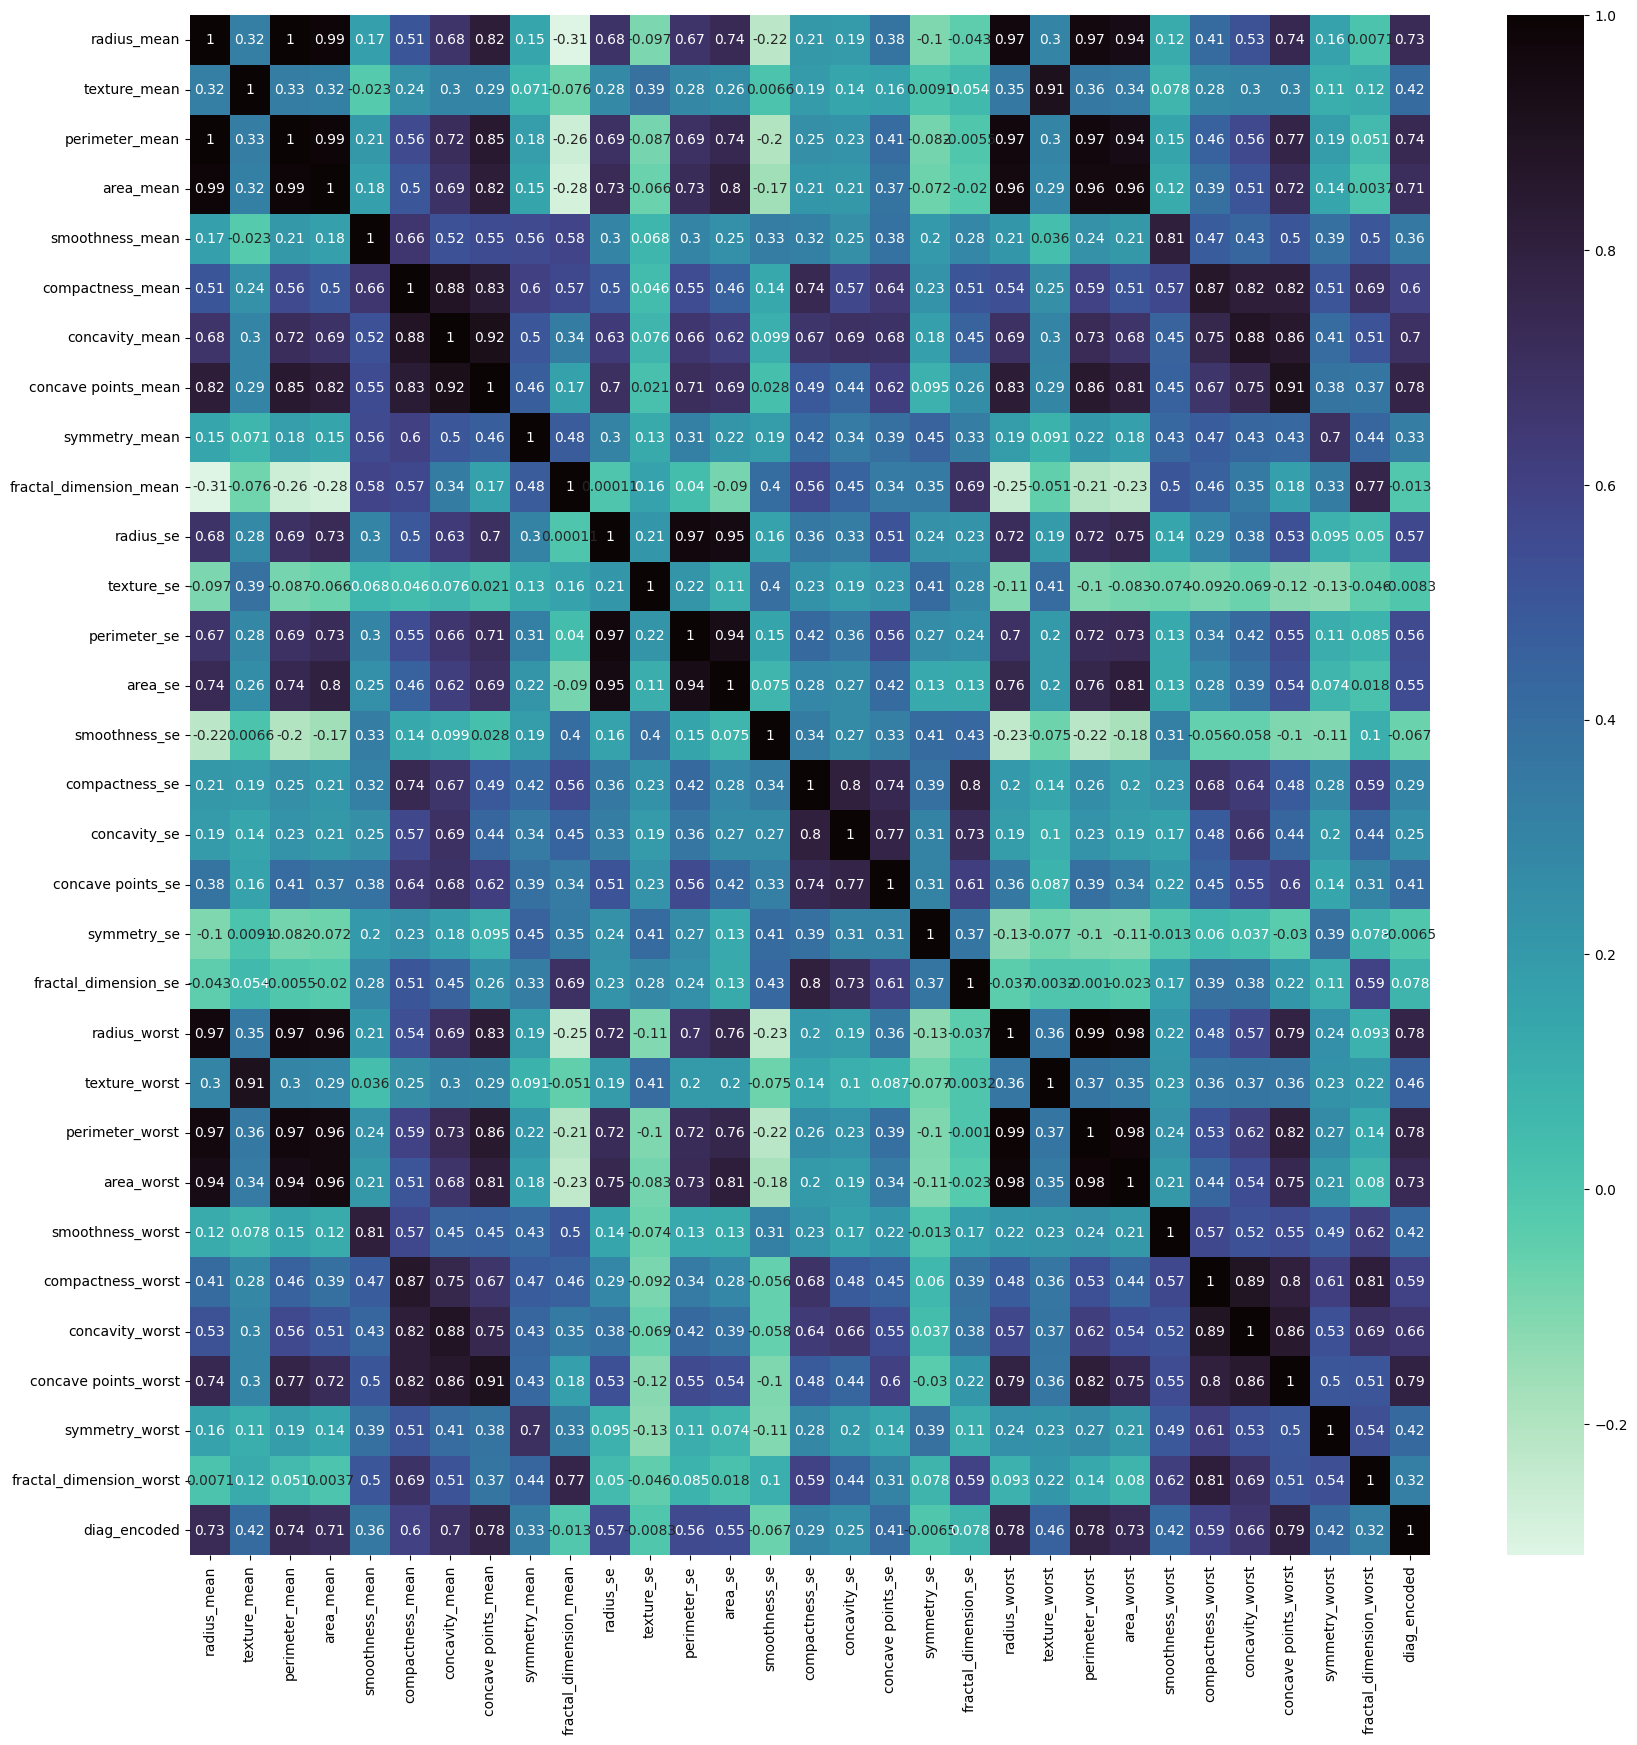

In [7]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), cmap='mako_r',annot=True)
plt.show()
# df.info()

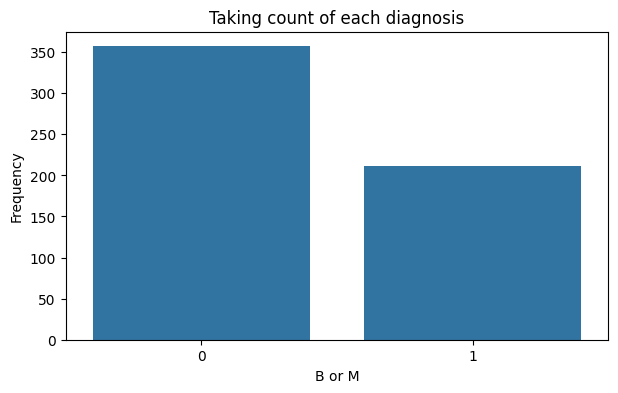

In [8]:
# Count plot
plt.figure(figsize=(7,4))
sns.countplot(x='diag_encoded', data=df)

plt.title("Taking count of each diagnosis")
plt.xlabel("B or M")
plt.ylabel("Frequency")

# plt.xticks(rotation=90)
plt.show()

In [9]:
X = df.drop('diag_encoded', axis=1)
y = df['diag_encoded']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [21]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
predictions = model.predict(X_test)

In [23]:
# testing accuracy

accuracy = accuracy_score(y_test, predictions)

In [24]:
accuracy

0.9824561403508771

In [25]:
# predictions = model.predict(X_train)

In [27]:
# training accuracy
# accuracy = accuracy_score(y_train, predictions)
# accuracy

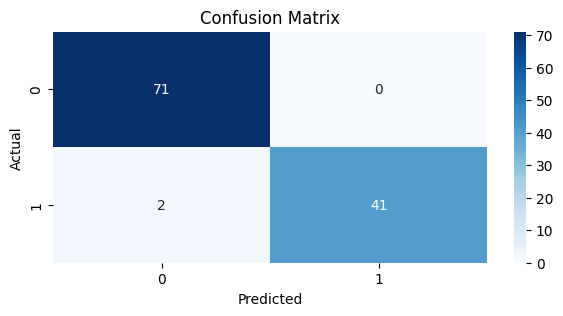

In [28]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
# Probably doe to the inbalance in the dataset target variable, it is able to predict 0 better than 1. But it is still not bad

In [30]:
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Precision: 0.99
Recall: 0.98
F1 Score: 0.98


In [35]:
classification_rep = classification_report(y_test, predictions)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



ROC AUC: 0.9767


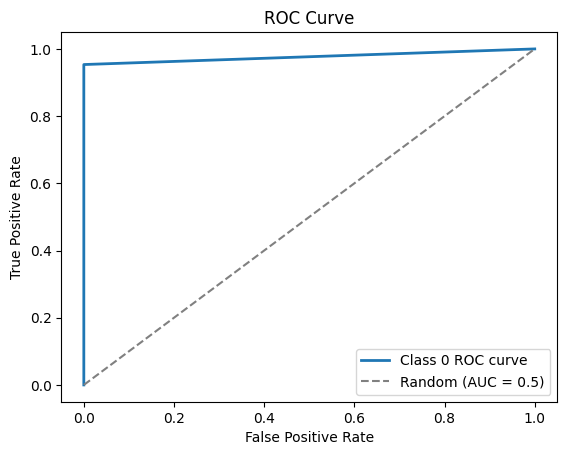

In [40]:
roc_auc = roc_auc_score(y_test, predictions, multi_class='ovr')

print(f'ROC AUC: {roc_auc:.4f}')

# Plotting ROC Curve for one class (e.g., class 0)
fpr, tpr, _ = roc_curve(y_test, predictions)
plt.plot(fpr, tpr, label='Class 0 ROC curve', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Decision Trees

In [41]:
from sklearn.tree import DecisionTreeClassifier

model_2 = DecisionTreeClassifier(criterion="gini")
# entropy
# log_loss

In [42]:
model_2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
predictions = model_2.predict(X_test)

In [44]:
from sklearn.metrics import 

accuracy = accuracy_score(y_test, predictions)
accuracy

0.9122807017543859

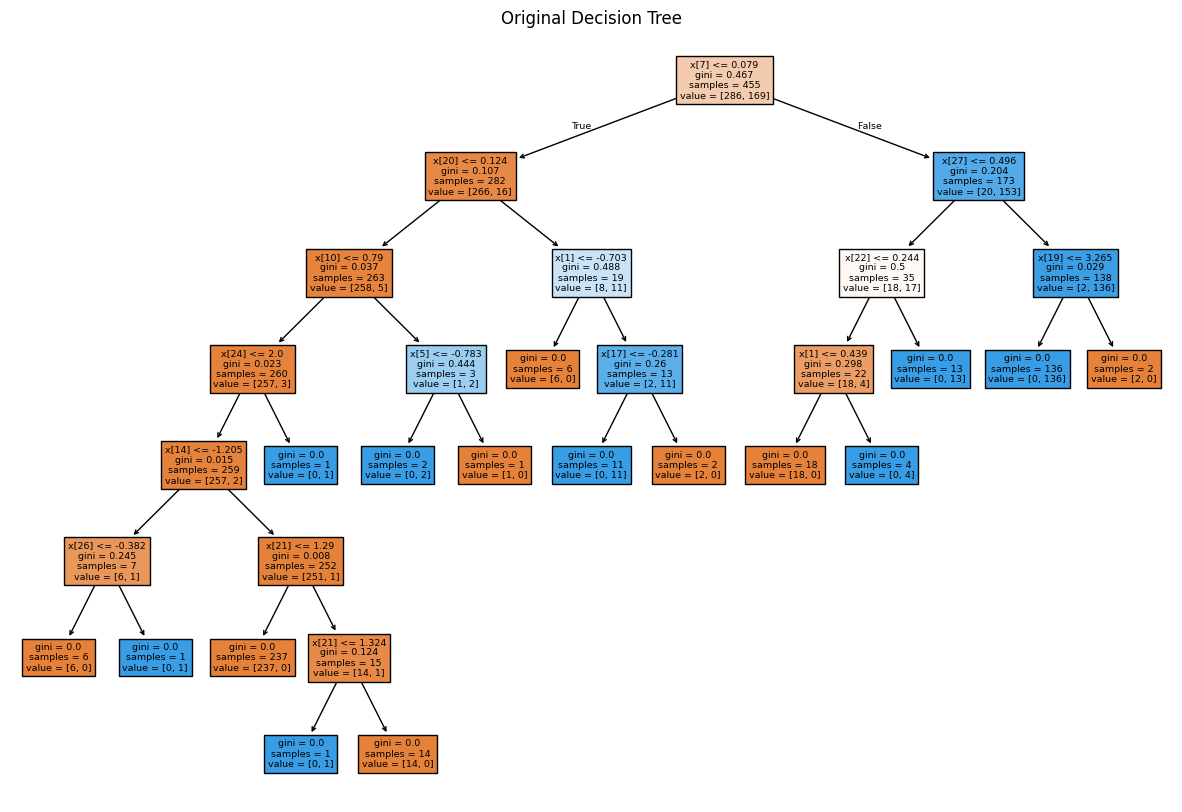

In [50]:
plt.figure(figsize=(15, 10))
plot_tree(model_2, filled=True)
plt.title("Original Decision Tree")
plt.show()

In [53]:
# Pre-pruning is just like carrying out GridSerachCV 

In [55]:
parameter = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [1,2,3,4,5],
    'max_features': ['sqrt', 'log2']
}

model = DecisionTreeClassifier()
cv = GridSearchCV(model, param_grid=parameter, cv=5)
cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['entropy', 'gini', ...], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [56]:
cv.score(X_test,y_test)
cv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [57]:
model_again = DecisionTreeClassifier(criterion="gini", max_depth=5, max_features = 'sqrt', splitter='best')
model_again.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [58]:
predictions = model_again.predict(X_test)


In [59]:
accuracy = accuracy_score(y_test, predictions)
accuracy

0.9385964912280702

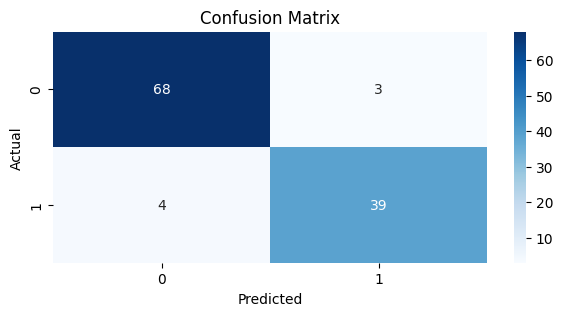

In [60]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [61]:
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Precision: 0.94
Recall: 0.93
F1 Score: 0.93


In [62]:
classification_rep = classification_report(y_test, predictions)
print(classification_rep)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



### Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
model_3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_3.fit(X_train, y_train)
y_pred = model_3.predict(X_test)

In [65]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9649122807017544

In [79]:
df.columns[0:30]

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [77]:
feature_importances

array([0.04870337, 0.01359088, 0.05326975, 0.04755501, 0.00728533,
       0.01394433, 0.06800084, 0.10620999, 0.00377029, 0.00388577,
       0.02013892, 0.00472399, 0.01130301, 0.02240696, 0.00427091,
       0.00525322, 0.00938583, 0.00351326, 0.00401842, 0.00532146,
       0.07798688, 0.02174901, 0.06711483, 0.15389236, 0.01064421,
       0.02026604, 0.0318016 , 0.14466327, 0.01012018, 0.00521012])

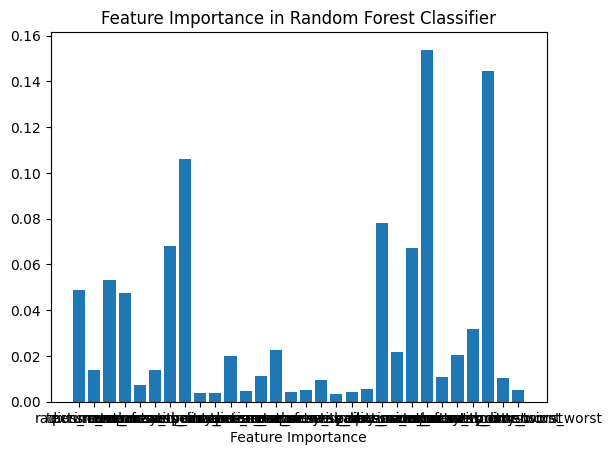

In [80]:
feature_importances = model_3.feature_importances_

plt.barh(df.columns[0:30], feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

### Evaluation metrics in confusion matrix

In [ ]:
# Accuracy, precision, recall, F1 score, ROC-AUC
# classification report
# confusion matrix
# precision-recall curve